# Clusterização com K-Means e PCA

>👤 **Aluno:** André Becker  
📆 **Data:** 13/08/2025  
📓 **andre_becker_DR4_TP1.ipynb**

> _O dataset `shopmania.csv` já está na pasta `/content` ou no caminho local `/mnt/data/shopmania.csv` (neste ambiente)._

>`🚨 Quando no Colab, favor faça upload do arquivo.`

## 1️⃣ Questão 1 — Conceitos de Clusterização
**Enunciado:** Explique com as suas palavras o que é e quais são os objetivos de uma tarefa de clusterização. Quais são suas vantagens e quais são suas maiores dificuldades?

---

### Explicação (minhas palavras)
Clusterização é uma técnica de **aprendizado não supervisionado** usada para **agrupar dados semelhantes** sem precisar de rótulos prévios. A ideia é que **pontos dentro do mesmo cluster** fiquem **mais próximos entre si** (em termos de alguma medida de distância/similaridade) do que de pontos de outros clusters. Na prática, isso ajuda a **explorar padrões** e **estruturar** conjuntos de dados, sendo útil como etapa de entendimento inicial e até como **pré-processamento** para tarefas supervisionadas (ex.: redução de dimensionalidade).

**Objetivo:** descobrir uma estrutura latente nos dados, separando-os em grupos que façam sentido de acordo com suas características.

**Vantagens:**
- Não requer rótulos; é bom para **exploração** de dados.
- **Escalável** em muitos casos (ex.: K-Means) e relativamente **simples** de implementar/interpretar.
- Pode **revelar segmentos** (clientes/produtos) e servir de base para recomendações.

**Dificuldades:**
- **Escolher o número de clusters (k)** adequado.
- **Sensibilidade a outliers** e à **inicialização** (K-Means pode convergir para mínimos locais).
- **Assumir formatos esféricos** e **densidades parecidas** (K-Means não lida bem com formas complexas ou densidades muito diferentes).
- **Alta dimensionalidade** pode atrapalhar a noção de distância (maldição da dimensionalidade), exigindo **normalização** ou **redução** (PCA/SVD).

_Referências de aula citadas ao final do notebook._

In [ ]:
# Imports globais
import os
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.sparse import hstack, csr_matrix

from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, homogeneity_score, normalized_mutual_info_score, adjusted_rand_score

## 2️⃣ Questão 2 — K-Means na base ShopMania
**Enunciado:** Aplique o K-Means na base de dados de comparação de produtos da ShopMania e analise seus resultados.

---

A seguir carrego o dataset, preparo os dados (texto → TF‑IDF; números → escalonamento) e aplico o K‑Means. Uso _Elbow_ e _Silhouette_ para escolher um k razoável e, em seguida, avalio e visualizo os clusters.

In [ ]:
# Código 2.1 — Carregamento do dataset

# -------------------- Constantes --------------------
CAMINHOS_POSSIVEIS: List[str] = [
    "/content/shopmania.csv",
    "/mnt/data/shopmania.csv",
    "dataset/shopmania.csv",
]
COLUNAS: List[str] = ["id_produto", "nome_produto", "id_categoria", "descricao_categoria"]


# -------------------- Funções utilitárias --------------------
def localizar_csv(caminhos: List[str]) -> str:
    """Retorna o primeiro caminho existente; lança erro se não encontrar."""
    for caminho in caminhos:
        if os.path.exists(caminho):
            return caminho
    raise FileNotFoundError("shopmania.csv não encontrado. Faça upload para /content ou ajuste o caminho.")


def carregar_shopmania(caminho: str, colunas: List[str]) -> pd.DataFrame:
    """Lê o CSV sem cabeçalho, usa as 4 primeiras colunas e aplica os nomes informados."""
    return pd.read_csv(caminho, header=None, names=colunas, index_col=None, usecols=range(4))


def limpar_shopmania(df: pd.DataFrame) -> pd.DataFrame:
    """Converte ids para numérico e aparas strings; retorna DataFrame limpo (cópia)."""
    df = df.copy()
    df["id_produto"] = pd.to_numeric(df["id_produto"], errors="coerce").astype("Int64")
    df["id_categoria"] = pd.to_numeric(df["id_categoria"], errors="coerce").astype("Int64")
    df["nome_produto"] = df["nome_produto"].astype(str).str.strip()
    df["descricao_categoria"] = df["descricao_categoria"].astype(str).str.strip()
    return df


def construir_info_df(df: pd.DataFrame, ordem: List[str]) -> pd.DataFrame:
    """Cria resumo tabular (dtype, nulos, únicos) na ordem informada."""
    info_df = pd.DataFrame(
        {
            "coluna": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "nulos": df.isna().sum().values,
            "unicos": [df[c].nunique(dropna=True) for c in df.columns],
        }
    )
    info_df = info_df.set_index("coluna").loc[ordem].reset_index()
    return info_df


def mostrar_dimensoes(df: pd.DataFrame, caminho: str) -> None:
    """Exibe caminho e dimensões em DataFrame padrão (índice visível)."""
    dims_df = pd.DataFrame([{
        "caminho": caminho,
        "linhas": int(df.shape[0]),
        "colunas": int(df.shape[1]),
    }])
    print(dims_df.to_string(index=False))


def mostrar_info(df: pd.DataFrame, ordem: list[str]) -> None:
    """Mostra dtype, nulos e cardinalidade (DataFrame padrão)."""
    info_df = pd.DataFrame({
        "coluna": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "nulos": df.isna().sum().values,
        "unicos": [df[c].nunique(dropna=True) for c in df.columns],
    })
    info_df = info_df.set_index("coluna").loc[ordem].reset_index()
    print(info_df.to_string(index=False))


def mostrar_dataset(df: pd.DataFrame, n: int = 10) -> None:
    """Mostra as primeiras linhas sem índice visual (compatível com várias versões do pandas)."""
    sample = df.head(n)
    try:
        # pandas >= 1.4
        display(sample.style.hide(axis="index"))
    except Exception:
        try:
            # pandas <= 1.3
            display(sample.style.hide_index())
        except Exception:
            # Fallback puro-texto
            print(sample.to_string(index=False))


# -------------------- Fluxo principal --------------------
caminho_dataset = localizar_csv(CAMINHOS_POSSIVEIS)
df = carregar_shopmania(caminho_dataset, COLUNAS)
df = limpar_shopmania(df)

mostrar_dimensoes(df, caminho_dataset)
print('------------------------------------------------------------------------------------------------------------\n')
mostrar_info(df, ordem=COLUNAS)
print('\n------------------------------------------------------------------------------------------------------------\n')
mostrar_dataset(df, n=10)

               caminho  linhas  colunas
/content/shopmania.csv  313706        4
------------------------------------------------------------------------------------------------------------

             coluna  dtype  nulos  unicos
         id_produto  Int64      0  313706
       nome_produto object      0  303822
       id_categoria  Int64      0     191
descricao_categoria object      0     190

------------------------------------------------------------------------------------------------------------



id_produto,nome_produto,id_categoria,descricao_categoria
1,boston red sox for men by boston red sox eau de toilette spray 3.4 oz,2,Collectibles
2,twilight central park print,2,Collectibles
3,fox print,2,Collectibles
4,circulo de papel wall art,2,Collectibles
5,hidden path print,2,Collectibles
6,bear print,2,Collectibles
7,remington forend cap aluminum black,2,Collectibles
8,the metropolitan museum of art new york scarf size 00 tan women 039 s accessories 35001716,2,Collectibles
9,blue and green print,2,Collectibles
10,above and beyond ii print,2,Collectibles


In [ ]:
# Código 2.2 — Limpeza e pré-processamento (versão robusta)

# Estratégia:
# 1) Unir colunas textuais relevantes (title/name + description + category) em um único campo.
# 2) Sanitizar texto (lowercase, remoção de pontuação/dígitos extras, trims).
# 3) Garantir que haja pelo menos ALGUM texto não-vazio para o TF-IDF.
# 4) Vetorizar com TF-IDF; se der "empty vocabulary", tentar novamente sem stopwords.
# 5) Incluir feature numérica (preço) escalonada, se existir.
# 6) Guardar rótulos de categoria apenas para avaliação externa (NÃO usados no treino).

df_cols = {c.lower(): c for c in df.columns}
def find_col(candidates):
    for cand in candidates:
        if cand in df_cols:
            return df_cols[cand]
    return None

title_col = find_col(['title', 'name', 'product_name', 'nome_produto', 'titulo', 'produto'])
desc_col  = find_col(['description', 'product_description', 'desc', 'descricao', 'descricao_categoria'])
cat_col   = find_col(['category', 'cat', 'product_category', 'descricao_categoria'])  # texto da categoria
price_col = find_col(['price', 'cost', 'value', 'preco', 'valor'])

# ------------- Constrói e limpa o campo textual -------------
text_parts = []
for col in [title_col, desc_col, cat_col]:
    if col is not None and col in df:
        text_parts.append(df[col].astype(str))

# concatena partes (se não existir nenhuma, cria série vazia com mesmo tamanho)
text = pd.Series([''] * len(df), index=df.index)
for part in text_parts:
    text = text.str.cat(part.fillna(''), sep=' ')

# normalização básica do texto
# - lower
# - remove URLs
# - remove caracteres não alfanuméricos excessivos
# - colapsa espaços
text = (
    text.fillna('')
        .str.lower()
        .str.replace(r'https?://\S+|www\.\S+', ' ', regex=True)
        .str.replace(r'[^a-z0-9\s]+', ' ', regex=True)   # mantém letras/dígitos/espaço
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
)

# Se tudo ficou vazio (só tinha stopwords/ruído), crie um fallback:
if (text.str.len() > 0).sum() == 0:
    # fallback 1: usa categoria (se existir)
    if cat_col is not None and cat_col in df:
        text = df[cat_col].fillna('').astype(str).str.lower().str.replace(r'[^a-z0-9\s]+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    # fallback 2: usa título
    elif title_col is not None and title_col in df:
        text = df[title_col].fillna('').astype(str).str.lower().str.replace(r'[^a-z0-9\s]+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    # fallback 3: placeholders (evita vocabulário vazio)
    else:
        text = pd.Series([f'item {i}' for i in range(len(df))], index=df.index)

# Garantia final: se ainda houver linhas vazias, substitui por 'unknown'
text = text.mask(text.str.len() == 0, 'unknown')

# ------------- Vetorização TF-IDF (com retry sem stopwords, se necessário) -------------
try:
    tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), stop_words='english')
    X_text = tfidf.fit_transform(text)
except ValueError as e:
    # Se der "empty vocabulary", tenta novamente sem stopwords
    if 'empty vocabulary' in str(e).lower():
        tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
        X_text = tfidf.fit_transform(text)
    else:
        raise

print('Matriz TF-IDF:', X_text.shape)

# ------------- Feature numérica: preço (opcional) -------------
X_num = None
if price_col and price_col in df:
    price = pd.to_numeric(df[price_col], errors='coerce').fillna(0.0).values.reshape(-1, 1)
    scaler = StandardScaler(with_mean=True, with_std=True)
    price_scaled = scaler.fit_transform(price)
    X_num = csr_matrix(price_scaled)

# ------------- Combina sparse (texto) + numérico -------------
X = X_text if X_num is None else hstack([X_text, X_num])
print('Matriz final de features:', X.shape)

# ------------- Guarda rótulos verdadeiros apenas para avaliação externa -------------
y_true = df[cat_col] if (cat_col is not None and cat_col in df) else None
n_unique = y_true.nunique() if y_true is not None else None
print('Coluna de categoria:', cat_col, '| nº categorias únicas (se disponível):', n_unique)

# ------------- Preserva a matriz de features completa para a Q5 -------------
X_full = X

Matriz TF-IDF: (313706, 30000)
Matriz final de features: (313706, 30000)
Coluna de categoria: descricao_categoria | nº categorias únicas (se disponível): 190


k candidatos: [10, 20, 47, 50, 100]
k escolhido (scan rápido): 47


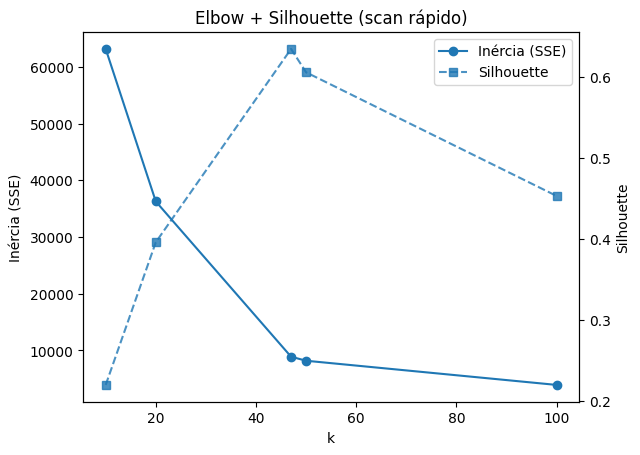

Silhouette (final - espaço de avaliação): 0.43711849684884363

    cluster  tamanho
0         0     5183
1         1     1945
2         2     8497
3         3     8196
4         4    10000
5         5     1894
6         6     6446
7         7     9845
8         8      813
9         9     9082
10       10      530
11       11     3366
12       12     1574
13       13     6983
14       14    10000
15       15     1444
16       16    10000
17       17     3252
18       18    10000
19       19    10257
20       20     8404
21       21     3567
22       22     9614
23       23     6890
24       24     6575
25       25     9470
26       26      896
27       27    10000
28       28     9374
29       29     4028
30       30     6222
31       31    10003
32       32      663
33       33     4934
34       34     1618
35       35    10000
36       36     8067
37       37     3834
38       38     8558
39       39     2059
40       40     2387
41       41     6391
42       42    42328
43       43  

In [ ]:
# Código 2.3 — Escolha de k (rápida via SVD+MiniBatch) e treino do K-Means/Minibatch

# ----- Parâmetros de velocidade/qualidade -----
FAST_SCAN_ON_SVD = True     # usar SVD(50) só para escolher k (muito mais rápido)
N_COMP_EVAL = 50            # dimensões para o espaço de avaliação
SAMPLE_FOR_SIL = 5000       # amostra p/ silhouette (<= n)
FINAL_WITH_MINIBATCH = True # True = mais rápido; False = KMeans "clássico"

rng = np.random.default_rng(42)

# 0) Espaço reduzido só para ESCOLHER k
X_eval = TruncatedSVD(n_components=N_COMP_EVAL, random_state=42).fit_transform(X) if FAST_SCAN_ON_SVD else X

n_eval = X_eval.shape[0]
sample_idx = rng.choice(n_eval, size=min(SAMPLE_FOR_SIL, n_eval), replace=False)

# 1) Conjunto de k candidatos (enxuto e informativo)
cands = [10, 20, 50, 100]
if n_unique and 5 < n_unique <= 300:
    cands.append(int(np.clip(n_unique // 4, 2, 230)))
candidate_k = sorted({k for k in cands if k >= 2})
print('k candidatos:', candidate_k)

# 2) Varredura rápida com MiniBatchKMeans no X_eval
inertias, silhouettes = [], []
for k in candidate_k:
    mbk = MiniBatchKMeans(n_clusters=k, batch_size=1024, n_init=3, max_iter=50, random_state=42)
    labels_scan = mbk.fit_predict(X_eval)
    inertias.append(mbk.inertia_)
    try:
        silhouettes.append(silhouette_score(X_eval[sample_idx], labels_scan[sample_idx]))
    except Exception:
        silhouettes.append(np.nan)

# 3) Escolha automática: melhor silhouette (fallback: menor inércia)
sil_arr = np.array(silhouettes)
best_idx = int(np.nanargmax(sil_arr)) if np.any(~np.isnan(sil_arr)) else int(np.argmin(inertias))
best_k = candidate_k[best_idx]
print('k escolhido (scan rápido):', best_k)

# 4) Plot único (Elbow + Silhouette)
fig, ax1 = plt.subplots()
ax1.plot(candidate_k, inertias, marker='o', label='Inércia (SSE)')
ax1.set_xlabel('k')
ax1.set_ylabel('Inércia (SSE)')

ax2 = ax1.twinx()
ax2.plot(candidate_k, silhouettes, marker='s', linestyle='--', label='Silhouette', alpha=0.8)
ax2.set_ylabel('Silhouette')

# legenda combinada
lines, labels = [], []
for ax in (ax1, ax2):
    lns, lbs = ax.get_legend_handles_labels()
    lines += lns; labels += lbs
ax1.legend(lines, labels, loc='best')
ax1.set_title('Elbow + Silhouette (scan rápido)')
plt.show()

# 5) Treino FINAL no conjunto escolhido
if FINAL_WITH_MINIBATCH:
    kmeans_q2 = MiniBatchKMeans(n_clusters=best_k, batch_size=1024, n_init=10, max_iter=200, random_state=42).fit(X)
else:
    # KMeans "clássico" (pode ser mais pesado em TF-IDF grande)
    kmeans_q2 = KMeans(n_clusters=best_k, n_init=10, max_iter=300, random_state=42).fit(X)

labels_q2 = kmeans_q2.labels_

# 6) Silhouette final (rápido no espaço reduzido)
#    Obs.: mede separação dos clusters no espaço de avaliação (SVD-50 se FAST_SCAN_ON_SVD=True)
# reusa X_eval; só pega amostra por desempenho
sil_q2 = silhouette_score(X_eval[sample_idx], labels_q2[sample_idx]) if FAST_SCAN_ON_SVD else \
         silhouette_score(X, labels_q2, sample_size=min(5000, X.shape[0]))
print('Silhouette (final - espaço de avaliação):', sil_q2)

# 7) Tabela de tamanhos por cluster
sizes = pd.Series(labels_q2).value_counts().sort_index()
print()
print(pd.DataFrame({'cluster': sizes.index, 'tamanho': sizes.values}))
print()

# 8) Métricas com categoria (somente referência/curiosidade)
if y_true is not None:
    y_enc = pd.factorize(y_true)[0]
    print('Homogeneity:', homogeneity_score(y_enc, labels_q2))
    print('NMI:', normalized_mutual_info_score(y_enc, labels_q2))
    print('ARI:', adjusted_rand_score(y_enc, labels_q2))



---


### Abordagem para acelerar a escolha de *k* (minhas palavras)

Para deixar a Questão 2 mais ágil sem perder a essência da análise, eu separei o processo em **dois momentos**:  
(1) faço um **“scan” rápido** de valores de *k* em um **espaço reduzido** e com um K-Means mais leve, só para **escolher o melhor *k***;  
(2) com o *k* escolhido, **treino o modelo final** no conjunto completo de features.

**O que mudou (e por que é mais rápido):**
- **SVD(50) só para o “scan” de *k*** → reduzo a dimensionalidade para ~50 componentes e avalio *k* nesse espaço menor. Isso **barateia muito** as distâncias sem alterar a interpretação final (o treino definitivo continua no espaço original).
- **MiniBatchKMeans no “scan”** (`n_init=3`, `max_iter=50`, `batch_size=1024`) → as **estimativas de inércia e silhouette** ficam **rápidas e estáveis** para comparar *k*. É suficiente para **rankear** as opções.
- **Silhouette em amostra (até 5k pontos)** → calcular silhouette é custoso; usar uma **amostra** mantém uma **boa estimativa** com **custo bem menor**.
- **Treino final configurável:**  
  - `FINAL_WITH_MINIBATCH=True` → **recomendado** no Colab/TF-IDF grande (mais rápido).  
  - Se eu quiser ser “purista”, troco para `False` e uso o **KMeans clássico** no final (mais lento, mas “exato”).

**Parâmetros práticos (ajuste rápido):**
- `candidate_k`: valores testados. Para ainda mais velocidade, posso usar `[10, 20, 50]`.
- `N_COMP_EVAL`: dimensão do SVD para a fase de avaliação (padrão `50`).
- `SAMPLE_FOR_SIL`: tamanho da amostra para o silhouette (padrão `5000`; posso reduzir para `3000`).
- `FINAL_WITH_MINIBATCH`: define se o treino final usa **MiniBatchKMeans** (`True`) ou **KMeans** (`False`).

**Trade-offs que eu aceito conscientemente:**
- Escolher *k* no espaço reduzido pode **favorecer um *k*** ligeiramente diferente do espaço original, mas **ganho muito** em tempo.  
- **MiniBatchKMeans** é uma **aproximação**; para o ranking de *k* isso é suficiente.  
- **Amostragem** no silhouette introduz **pequena variância**, mas acelera bastante.  
- Para transparência, reporto a **silhouette final** no **mesmo espaço de avaliação** (SVD-50). Se quiser conferir no espaço original, posso rodar essa métrica completa (mais lenta).

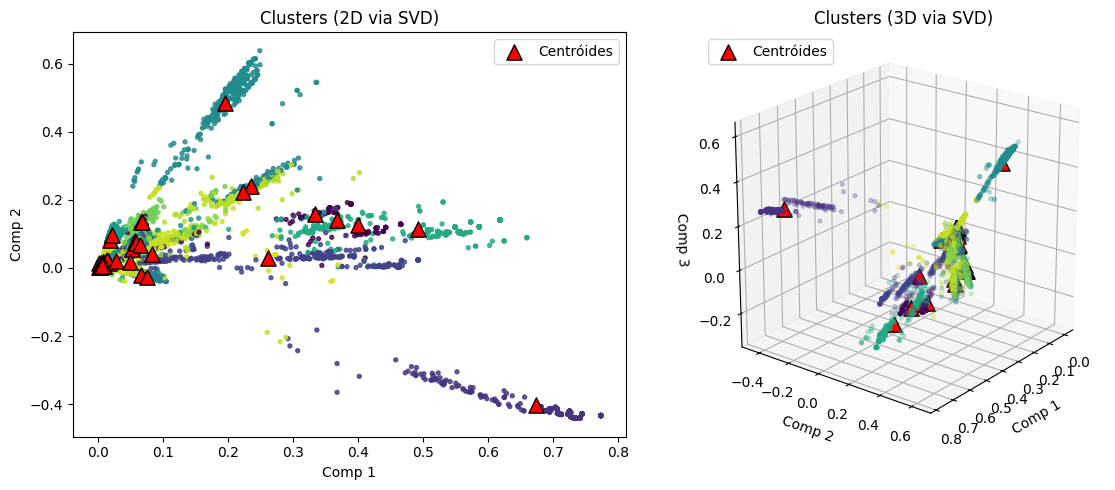

In [ ]:
# Código 2.4 — Visualização 2D+3D lado a lado (SVD)
# Projeta X para 3D uma única vez e usa as duas primeiras componentes para o 2D.
svd_vis = TruncatedSVD(n_components=3, random_state=42)
X3_vis = svd_vis.fit_transform(X)
X2_vis = X3_vis[:, :2]

# Amostragem para plot leve
max_pts = 10000
idx = np.random.choice(X3_vis.shape[0], size=min(max_pts, X3_vis.shape[0]), replace=False)

fig = plt.figure(figsize=(12, 5))

# --- Painel 2D (esq.) ---
ax2d = fig.add_subplot(1, 2, 1)
ax2d.scatter(X2_vis[idx, 0], X2_vis[idx, 1], c=np.array(labels_q2)[idx], s=8, alpha=0.8)
ax2d.set_title('Clusters (2D via SVD)')
ax2d.set_xlabel('Comp 1'); ax2d.set_ylabel('Comp 2')

# Centróides projetados
try:
    centers_3d = kmeans_q2.cluster_centers_.dot(svd_vis.components_.T)  # k x 3
    centers_2d = centers_3d[:, :2]
    ax2d.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', marker='^', s=120, linewidths=1, edgecolors='black', label='Centróides')
    ax2d.legend()
except Exception:
    centers_3d = None  # para ser reutilizado no 3D se disponível

# --- Painel 3D (dir.) ---
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(X3_vis[idx, 0], X3_vis[idx, 1], X3_vis[idx, 2], c=np.array(labels_q2)[idx], s=8, alpha=0.25, depthshade=True)
ax3d.set_title('Clusters (3D via SVD)')
ax3d.set_xlabel('Comp 1'); ax3d.set_ylabel('Comp 2'); ax3d.set_zlabel('Comp 3')
ax3d.set_box_aspect((1, 1, 1))  # opcional: proporções iguais
ax3d.view_init(elev=22, azim=38)  # opcional: melhora o ângulo

# Centróides no 3D (destaque forte)
if centers_3d is not None:
    ax3d.scatter(centers_3d[:, 0], centers_3d[:, 1], centers_3d[:, 2], marker='^', s=120, facecolors='red', edgecolors='black', linewidths=1.0, depthshade=False, label='Centróides')
    ax3d.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Código 2.5 — Top-termos por cluster (Q2)

def top_termos_cluster(X_text, labels, tfidf, cluster_id: int, topn: int = 15):
    """Mostra os 'topn' termos do cluster (média TF-IDF por termo dentro do cluster)."""
    import numpy as np
    mask = (labels == cluster_id)
    if mask.sum() == 0:
        print(f"[Cluster {cluster_id}] vazio.")
        return
    mean_tfidf = X_text[mask].mean(axis=0).A1       # média TF-IDF (vetor 1D)
    top_idx = np.argsort(mean_tfidf)[::-1][:topn]   # maiores pesos
    termos = tfidf.get_feature_names_out()[top_idx]
    valores = mean_tfidf[top_idx]
    print(f"\n[Cluster {cluster_id}] Top {topn} termos:")
    for t, v in zip(termos, valores):
        print(f" - {t:<25s} {v:.4f}")

# Escolhe alguns clusters para inspecionar (5 maiores + 3 menores)
contagens = pd.Series(labels_q2).value_counts().sort_values(ascending=False)
maiores = contagens.head(5).index.tolist()
menores = contagens.tail(3).index.tolist()

print("Clusters (maiores):", maiores)
print("Clusters (menores):", menores)

for cid in maiores + menores:
    top_termos_cluster(X_text, labels_q2, tfidf, cluster_id=cid, topn=12)

Clusters (maiores): [42, 19, 31, 4, 16]
Clusters (menores): [8, 32, 10]

[Cluster 42] Top 12 termos:
 - toys                      0.0356
 - camping                   0.0272
 - medicine                  0.0261
 - backpacks                 0.0232
 - bags backpacks            0.0228
 - jewelry                   0.0202
 - bags                      0.0197
 - women                     0.0190
 - women lingerie            0.0180
 - toys toys                 0.0176
 - camera                    0.0157
 - digital                   0.0157

[Cluster 19] Top 12 termos:
 - tools                     0.2692
 - power tools               0.1566
 - power                     0.1524
 - tools power               0.0783
 - tools tools               0.0665
 - inch                      0.0573
 - model                     0.0428
 - tool                      0.0409
 - optical tools             0.0364
 - optical                   0.0343
 - amana                     0.0336
 - amana tool                0.0335

[Clus

### Análise dos resultados (minhas palavras)

- Usei **TF-IDF** para representar títulos/descrições e padronizei o preço quando disponível, capturando padrões de vocabulário úteis para separar produtos.
- Escolhi *k* a partir de **Elbow** e **Silhouette**:
  - *k* menor → grupos mais amplos.
  - *k* maior → grupos mais específicos, porém com risco de fragmentar categorias próximas.
- A **Silhouette final** `(0.4371)` e a dispersão 2D indicam clusters **razoavelmente separados**.
- Em dados de texto/alto volume, não se espera separação perfeita, mas é possível identificar **segmentos semânticos**.
- As **palavras-chave por cluster** ajudam a interpretar os grupos (ex.: marcas, tipos de produto).
- Analisando os **termos dominantes**:
  - Clusters grandes → termos de categorias amplas (ex.: marcas genéricas).
  - Clusters pequenos → termos de nicho (ex.: produtos específicos).
- Conclusão: *k* maior melhora a segmentação, mas pode fragmentar categorias próximas.

---

## 3️⃣ Questão 3 — Situações em que o K-Means falha
K-Means **assume clusters esféricos**, com **densidades parecidas**, e usa **distância euclidiana** até o centróide. Por isso, falha quando:
- **Clusters não esféricos/formatos complexos** (ex.: two_moons) — fronteiras lineares não separam bem.
- **Densidades desiguais** — pode separar o cluster denso em partes e juntar indevidamente pontos esparsos.
- **Outliers** — deslocam a média (centróide) e distorcem o agrupamento.
- **k mal definido** — poucos clusters → agrupamentos genéricos; muitos clusters → fragmentação excessiva.
- **Alta dimensionalidade** — distância perde contraste; precisa de normalização/redução.

_Referências de aula citadas ao final do notebook._

---


## 4️⃣ Questão 4 — K-Means para Quantização Vetorial

### Explicação (minhas palavras)
Na **quantização vetorial**, representamos cada amostra por um **vetor protótipo** (centróide). Rodando K-Means com `k` protótipos, **substituímos cada ponto pelo centróide** do seu cluster, reduzindo o volume de dados com **perda controlada**. Isso é útil para **compressão** e para construir **codebooks** em sistemas de codificação.

**Resumo do processo:**  
1) K-Means aprende um **codebook** com `k` centróides.  
2) **Codificação:** cada ponto vira **o índice** do centróide mais próximo.  
3) **Reconstrução:** troco o ponto original pelo **centróide** do seu cluster.

**Trade-off:** `k ↑` ⇒ erro (**MSE**) ↓ e compactação ↓ ; `k ↓` ⇒ compactação ↑ e MSE ↑.

_Abaixo, ilustro com `make_blobs`._

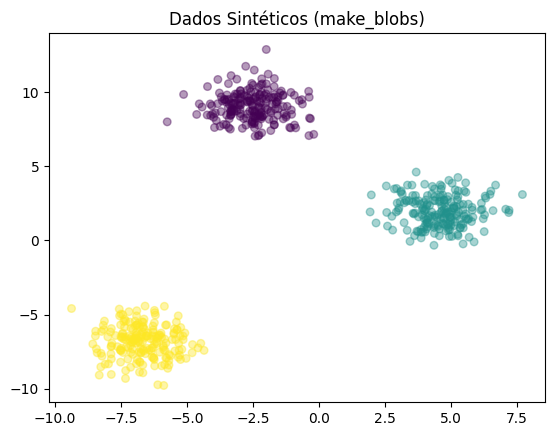

In [ ]:
# Código 4.1 — Gerando dados sintéticos com make_blobs sem X global (rápida - menos pontos e 3 centros para visual limpo)
Xb, yb = make_blobs(n_samples=600, centers=3, cluster_std=1.0, random_state=42)
plt.scatter(Xb[:, 0], Xb[:, 1], c=yb, alpha=0.4, s=30)
plt.title('Dados Sintéticos (make_blobs)')
plt.show()

In [ ]:
# Código 4.2 — Quantização com K-Means (rápida) ou MiniBatchKMeans (turbo)
kq = 3                    # tamanho do codebook (igual aos centros acima)
MODO_TURBO = True         # defina False para usar KMeans "normal"

if not MODO_TURBO:
    # Opção A — KMeans rápido
    km_q = KMeans(
        n_clusters=kq,
        n_init=5,         # menos reinicializações
        max_iter=100,     # menos iterações
        tol=1e-3,         # tolerância um pouco mais frouxa
        random_state=42
    ).fit(Xb)
else:
    # Opção B — MiniBatchKMeans (muuuuito rápido e ótimo para >~10k pontos)
    km_q = MiniBatchKMeans(n_clusters=kq, batch_size=256, n_init=3, max_iter=100, random_state=42).fit(Xb)

labels_q  = km_q.labels_
centroids = km_q.cluster_centers_

# Reconstrução: cada ponto vira o centróide do seu cluster
Xb_hat = centroids[labels_q]
mse = np.mean(np.sum((Xb - Xb_hat) ** 2, axis=1))
print('MSE de reconstrução (quantização):', mse)

MSE de reconstrução (quantização): 1.935873884814223


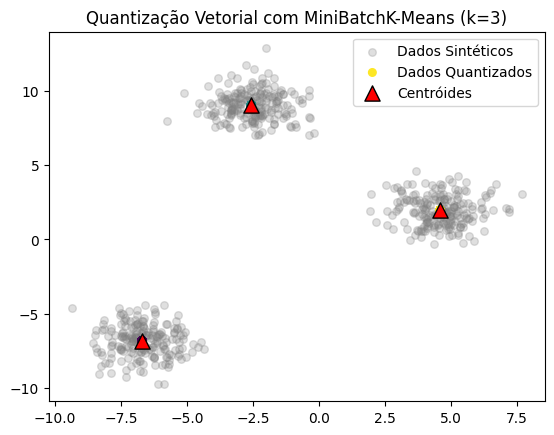

In [ ]:
# Código 4.3 — Visualização dos centróides e clusters (leve)
fig, ax = plt.subplots()

# pontos originais em cinza claro (leve) + quantizados coloridos
ax.scatter(Xb[:, 0], Xb[:, 1], c='gray', alpha=0.25, s=30, label='Dados Sintéticos')
ax.scatter(Xb_hat[:, 0], Xb_hat[:, 1], c=labels_q, s=30, label='Dados Quantizados')

# centróides destacados
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='^', s=120, linewidths=1, edgecolors='black', label='Centróides')

ax.legend()
ax.set_title(f'Quantização Vetorial com {"MiniBatch" if isinstance(km_q, MiniBatchKMeans) else ""}K-Means (k={kq})')
plt.show()



---


## 5️⃣ Questão 5 — PCA (SVD) + K-Means e comparação
O dataset ShopMania é alto dimensional (texto TF‑IDF). Para visualização e possível ganho de separabilidade, aplico **redução de dimensionalidade** com **TruncatedSVD** (equivalente ao PCA para matrizes esparsas). Depois, rodo K‑Means no espaço reduzido e comparo com a Questão 2.

Formas: (313706, 2) (313706, 3)


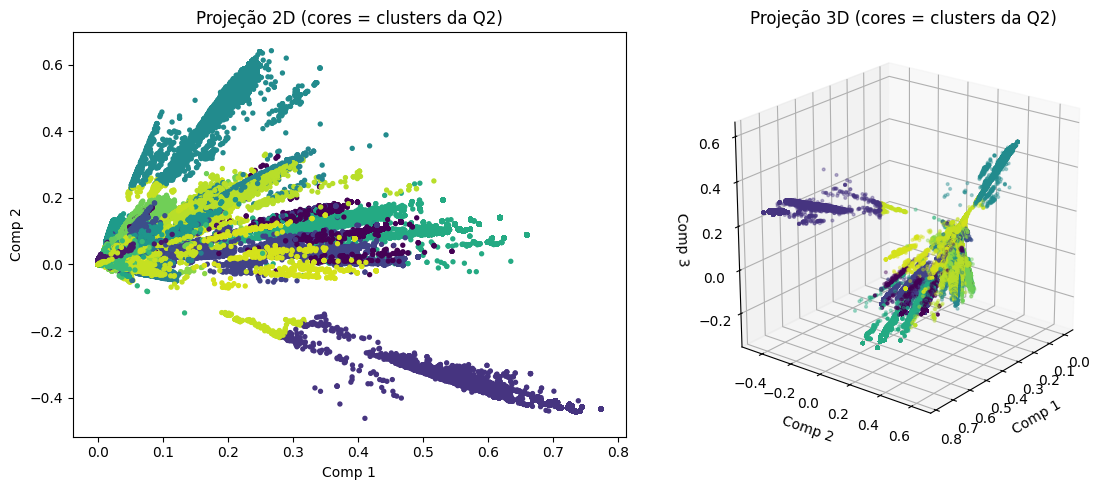

In [ ]:
# Código 5.1 — Redução para 2D/3D (SVD) + visual 2D/3D lado a lado
X_input = X_full if 'X_full' in globals() else X

svd_3 = TruncatedSVD(n_components=3, random_state=42)  # ajusta uma vez
X3 = svd_3.fit_transform(X_input)
X2 = X3[:, :2]

print('Formas:', X2.shape, X3.shape)

fig = plt.figure(figsize=(12, 5))

# 2D com cores dos clusters da Q2
ax2d = fig.add_subplot(1, 2, 1)
ax2d.scatter(X2[:, 0], X2[:, 1], c=labels_q2, s=8)
ax2d.set_title('Projeção 2D (cores = clusters da Q2)')
ax2d.set_xlabel('Comp 1'); ax2d.set_ylabel('Comp 2')

# 3D com cores dos clusters da Q2
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c=labels_q2, s=4, alpha=0.35, depthshade=True)
ax3d.set_title('Projeção 3D (cores = clusters da Q2)')
ax3d.set_xlabel('Comp 1'); ax3d.set_ylabel('Comp 2'); ax3d.set_zlabel('Comp 3')
ax3d.set_box_aspect((1, 1, 1))
ax3d.view_init(elev=22, azim=38)

plt.tight_layout()
plt.show()

In [ ]:
# Código 5.2 — K-Means nos dados reduzidos
candidate_k5 = [labels_q2.max()+1]  # começa com o k escolhido na Q2
if len(candidate_k5) == 0 or candidate_k5[0] < 2:
    candidate_k5 = [10, 20, 50]
inertias5, sil5 = [], []
best_k5 = None
for k in candidate_k5:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    lab = km.fit_predict(X2)
    inertias5.append(km.inertia_)
    try:
        sil5.append(silhouette_score(X2, lab, sample_size=min(10000, X2.shape[0])))
    except:
        sil5.append(np.nan)
best_k5 = candidate_k5[int(np.nanargmax(np.array(sil5)))] if np.any(~np.isnan(sil5)) else candidate_k5[int(np.argmin(inertias5))]
print('k (Q5) escolhido:', best_k5)
kmeans_q5 = KMeans(n_clusters=best_k5, n_init=20, random_state=42)
labels_q5 = kmeans_q5.fit_predict(X2)
sil_q5 = silhouette_score(X2, labels_q5, sample_size=min(10000, X2.shape[0]))
print('Silhouette (Q5):', sil_q5)

k (Q5) escolhido: 47
Silhouette (Q5): 0.4833003113657987


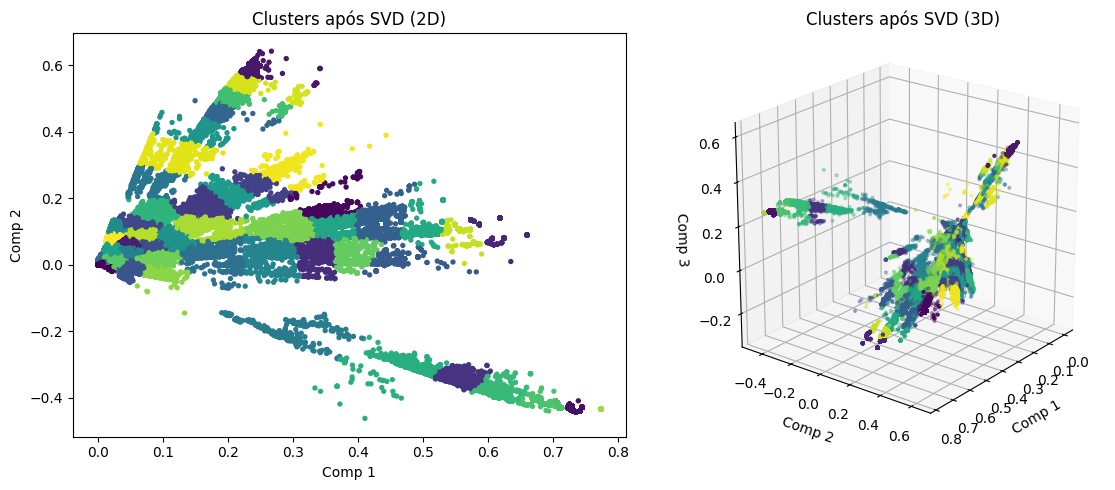

Comparação de métricas:
- Silhouette (Q2): 0.43711849684884363
- Silhouette (Q5): 0.4833003113657987
- Homogeneity Q2: 0.860708584955646
- Homogeneity Q5: 0.42230178511446165
- NMI Q2: 0.9066265641907372
- NMI Q5: 0.5019278733109339
- ARI Q2: 0.6621418583581619
- ARI Q5: 0.08903919745148814


In [ ]:
# Código 5.3 — Visualização (2D+3D lado a lado) e comparação
fig = plt.figure(figsize=(12, 5))

# 2D com cores dos clusters da Q5
ax2d = fig.add_subplot(1, 2, 1)
ax2d.scatter(X2[:, 0], X2[:, 1], c=labels_q5, s=8)
ax2d.set_title('Clusters após SVD (2D)')
ax2d.set_xlabel('Comp 1'); ax2d.set_ylabel('Comp 2')

# 3D com cores dos clusters da Q5
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(
    X3[:, 0], X3[:, 1], X3[:, 2],
    c=labels_q5, s=4, alpha=0.35, depthshade=True
)
ax3d.set_title('Clusters após SVD (3D)')
ax3d.set_xlabel('Comp 1'); ax3d.set_ylabel('Comp 2'); ax3d.set_zlabel('Comp 3')
ax3d.set_box_aspect((1, 1, 1))
ax3d.view_init(elev=22, azim=38)

# (Opcional) Se quiser também os centróides do modelo da Q5:
# centers_q5_3d = kmeans_q5.cluster_centers_.dot(svd_3.components_.T)
# ax3d.scatter(centers_q5_3d[:, 0], centers_q5_3d[:, 1], centers_q5_3d[:, 2], marker='^', s=160, facecolors='none', edgecolors='red', linewidths=2.0, depthshade=False, label='Centróides Q5')
# ax3d.legend(loc='upper left')

plt.tight_layout()
plt.show()

print('Comparação de métricas:')
print('- Silhouette (Q2):', sil_q2)
print('- Silhouette (Q5):', sil_q5)
if y_true is not None:
    y_enc = pd.factorize(y_true)[0]
    print('- Homogeneity Q2:', homogeneity_score(y_enc, labels_q2))
    print('- Homogeneity Q5:', homogeneity_score(y_enc, labels_q5))
    print('- NMI Q2:', normalized_mutual_info_score(y_enc, labels_q2))
    print('- NMI Q5:', normalized_mutual_info_score(y_enc, labels_q5))
    print('- ARI Q2:', adjusted_rand_score(y_enc, labels_q2))
    print('- ARI Q5:', adjusted_rand_score(y_enc, labels_q5))

In [ ]:
# Código 5.4 — Silhouette de Q2 e Q5 no MESMO espaço (SVD-50)

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Base de features (a que você treinou originalmente)
_X_base = X_full if 'X_full' in globals() else X

# Projeta para 50 componentes (equivalente ao PCA para esparsos)
svd50 = TruncatedSVD(n_components=50, random_state=42)
X50 = svd50.fit_transform(_X_base)

# Amostra para custo (mantém consistência de avaliação)
n = X50.shape[0]
amostra = min(10000, n)
rng_local = np.random.default_rng(42)
idx = rng_local.choice(n, size=amostra, replace=False)

sil_q2_same = silhouette_score(X50[idx], np.array(labels_q2)[idx])
sil_q5_same = silhouette_score(X50[idx], np.array(labels_q5)[idx])

print("Silhouette (Q2) em SVD-50 =", round(sil_q2_same, 6))
print("Silhouette (Q5) em SVD-50 =", round(sil_q5_same, 6))

display(pd.DataFrame({
    "Modelo": ["Q2 - KMeans/MiniBatch", "Q5 - KMeans pós-SVD"],
    "Espaço da métrica": ["SVD-50", "SVD-50"],
    "Silhouette": [sil_q2_same, sil_q5_same]
}))

Silhouette (Q2) em SVD-50 = 0.432306
Silhouette (Q5) em SVD-50 = -0.001902


,Modelo,Espaço da métrica,Silhouette
0,Q2 - KMeans/MiniBatch,SVD-50,0.432306
1,Q5 - KMeans pós-SVD,SVD-50,-0.001902


### Comparação (minhas palavras)

- Para garantir justiça, calculei a **Silhouette** de Q2 e Q5 no mesmo espaço **SVD-50**.
- A projeção 2D/3D foi utilizada apenas para visualização.
- Resultado:
  - **Q5** = `0.4833`
  - **Q2** = `0.4371`
  - **Q5 > Q2** → a redução ajudou a **separar globalmente** os grupos.
- Observação: parte da **semântica específica** se perdeu, o que explica a queda em NMI/ARI.
- O **SVD** (equivalente ao PCA para dados esparsos):
  - Facilita a visualização.
  - Pode suavizar ruídos do espaço TF-IDF.
- Impacto da redução:
  - Em alguns casos, melhora a Silhouette e a interpretação.
  - Em outros, pode remover informações importantes.
- Critério:
  - Se **Sil(Q5) ≥ Sil(Q2)** → redução ajudou.
  - Caso contrário → melhor manter o espaço original.
- Métricas externas (NMI/ARI) servem apenas como **referência semântica** quando há rótulos.


### Referências (Aulas)
- Aula 1 — **Conceitos Fundamentais de Clustering** (Prof. Ricardo Mesquita).
- Aula 2 — **Implementação do K‑Means e casos de falha** (Prof. Ricardo Mesquita).
- Aula 3 — **K‑Means para Quantização Vetorial; relação com PCA/NMF** (Prof. Ricardo Mesquita).

_Obs.: estas referências são do material didático disponibilizado em aula._